# Screentime, Sleep, and Stress Analysis

This project analyzes how smartphone usage habits influence productivity.  
Using the Smartphone Usage and Productivity Dataset, we apply data science techniques and machine learning models to predict **Work Productivity Score** based on lifestyle and smartphone usage patterns.

## **Data Cleaning**



In [ ]:
import pandas as pd

df = pd.read_csv("Smartphone_Usage_Productivity_Dataset_50000.csv")

# Check Dataset
df.head()

,User_ID,Age,Gender,Occupation,Device_Type,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
0,U1,58,Male,Professional,Android,1.3,6.7,6,8.8,4,42,1,8.7
1,U2,25,Male,Professional,Android,1.2,1.5,5,6.4,1,51,3,5.1
2,U3,19,Male,Student,iOS,5.3,5.7,5,9.0,4,14,5,6.3
3,U4,35,Female,Business Owner,iOS,5.8,2.5,2,5.7,3,36,6,12.8
4,U5,33,Male,Freelancer,Android,7.9,1.3,4,5.7,3,37,5,9.9


In [ ]:
df = df.sample(10000, random_state=42)

In [ ]:
# Check Missing Values
df.isnull().sum()

,0
User_ID,0
Age,0
Gender,0
Occupation,0
Device_Type,0
Daily_Phone_Hours,0
Social_Media_Hours,0
Work_Productivity_Score,0
Sleep_Hours,0
Stress_Level,0


In [ ]:
# Remove Duplicates
df = df.drop_duplicates()

In [ ]:
# Check Data Types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   User_ID                    50000 non-null  object 
 1   Age                        50000 non-null  int64  
 2   Gender                     50000 non-null  object 
 3   Occupation                 50000 non-null  object 
 4   Device_Type                50000 non-null  object 
 5   Daily_Phone_Hours          50000 non-null  float64
 6   Social_Media_Hours         50000 non-null  float64
 7   Work_Productivity_Score    50000 non-null  int64  
 8   Sleep_Hours                50000 non-null  float64
 9   Stress_Level               50000 non-null  int64  
 10  App_Usage_Count            50000 non-null  int64  
 11  Caffeine_Intake_Cups       50000 non-null  int64  
 12  Weekend_Screen_Time_Hours  50000 non-null  float64
dtypes: float64(4), int64(5), object(4)
memory usag

## **Exploratory Data Analysis (EDA)**

In [ ]:
# Summary Statistics
df.describe()

,Age,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000
mean,39.034960,6.509116,4.267250,5.503760,6.497744,5.504500,32.43898,3.004580,8.006844
std,12.414877,3.170903,2.164743,2.874806,1.449551,2.871095,16.12151,1.996657,3.461300
min,18.000000,1.000000,0.500000,1.000000,4.000000,1.000000,5.00000,0.000000,2.000000
25%,28.000000,3.800000,2.400000,3.000000,5.200000,3.000000,18.00000,1.000000,5.000000
50%,39.000000,6.500000,4.300000,5.500000,6.500000,6.000000,32.00000,3.000000,8.000000
75%,50.000000,9.200000,6.100000,8.000000,7.800000,8.000000,46.00000,5.000000,11.000000
max,60.000000,12.000000,8.000000,10.000000,9.000000,10.000000,60.00000,6.000000,14.000000


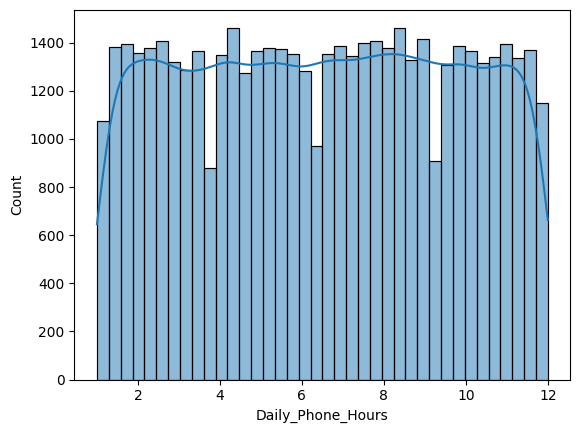

In [ ]:
# Distribution of Phone Usage
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['Daily_Phone_Hours'], kde=True)
plt.show()

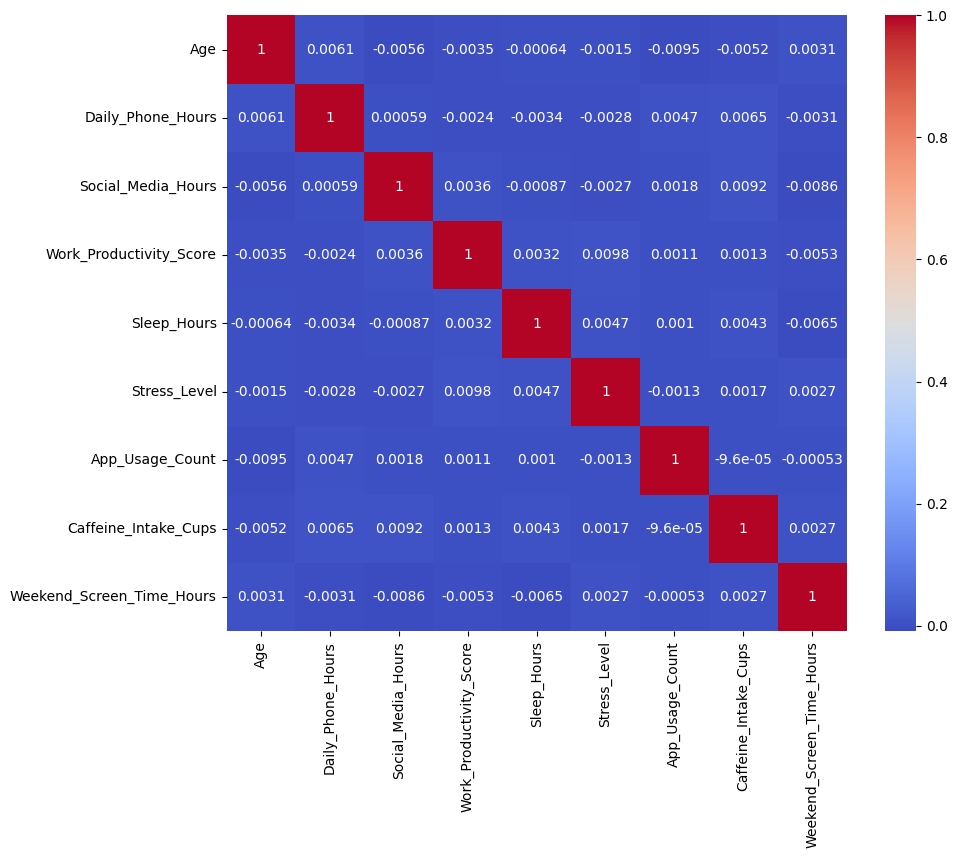

In [ ]:
# Correlation Analysis
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

Correlation analysis was conducted to determine relationships between smartphone usage variables and productivity scores.

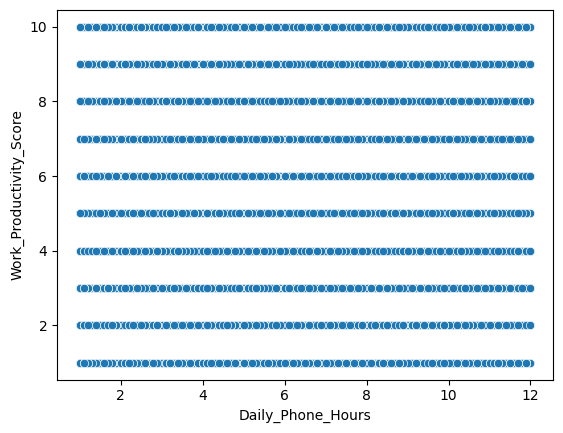

In [ ]:
# Scatter Plot
sns.scatterplot(x='Daily_Phone_Hours', y='Work_Productivity_Score', data=df)
plt.show()

## **Preprocessing**

In [ ]:
# Encode Categorical Variables
df = pd.get_dummies(df, drop_first=True)

In [ ]:
# Separate Features and Target
X = df.drop('Work_Productivity_Score', axis=1)
y = df['Work_Productivity_Score']

In [ ]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

## **Models to be Used**

In [ ]:
# Model 1: Linear Regression
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [ ]:
# Model 2: Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [ ]:
# Model 3: Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor()

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

## **Evaluation Metrics**

In [ ]:
# Evaluation Metrics for Linear Regression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Mean Absolute Error (MAE)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
print("Linear Regression MAE:", mae_lr)

# Root Mean Squared Error (RMSE)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
print("Linear Regression RMSE:", rmse_lr)

# R² Score
r2_lr = r2_score(y_test, y_pred_lr)
print("Linear Regression R2:", r2_lr)

Linear Regression MAE: 2.539887134899958
Linear Regression RMSE: 2.9352074151275196
Linear Regression R2: -0.025923489249070508


In [ ]:
# Evaluation Metrics for Random Forest Regressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# MAE
mae_rf = mean_absolute_error(y_test, y_pred_rf)
print("Random Forest MAE:", mae_rf)

# RMSE
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
print("Random Forest RMSE:", rmse_rf)

# R2
r2_rf = r2_score(y_test, y_pred_rf)
print("Random Forest R2:", r2_rf)

Random Forest MAE: 2.5295349999999996
Random Forest RMSE: 2.9360364354006236
Random Forest R2: -0.026503094953331807


In [ ]:
# Evaluation Metrics for Decision Tree Regressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# MAE
mae_dt = mean_absolute_error(y_test, y_pred_dt)
print("Decision Tree MAE:", mae_dt)

# RMSE
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
print("Decision Tree RMSE:", rmse_dt)

# R2
r2_dt = r2_score(y_test, y_pred_dt)
print("Decision Tree R2:", r2_dt)

Decision Tree MAE: 3.369
Decision Tree RMSE: 4.144393803682271
Decision Tree R2: -1.045311277806018


In [ ]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Decision Tree"],
    "MAE": [mae, mae_rf, mae_dt],
    "RMSE": [rmse, rmse_rf, rmse_dt],
    "R2 Score": [r2, r2_rf, r2_dt]
})

print(results)

               Model       MAE      RMSE  R2 Score
0  Linear Regression  2.539887  2.935207 -0.025923
1      Random Forest  2.529535  2.936036 -0.026503
2      Decision Tree  3.369000  4.144394 -1.045311


## **Deployment**

## Exploratory Data Analysis (EDA)

In [ ]:
# Dataset Shape
print("Dataset Shape:", df.shape)

Dataset Shape: (10000, 10014)


In [ ]:
# Data Types
print("\nData Types:")
print(df.dtypes)


Data Types:
Age                          int64
Daily_Phone_Hours          float64
Social_Media_Hours         float64
Work_Productivity_Score      int64
Sleep_Hours                float64
                            ...   
Gender_Other                  bool
Occupation_Freelancer         bool
Occupation_Professional       bool
Occupation_Student            bool
Device_Type_iOS               bool
Length: 10014, dtype: object


In [ ]:
# Summary Statistics
print("\nSummary Statistics:")
display(df.describe())


Summary Statistics:


,Age,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,38.956600,6.570000,4.263260,5.515200,6.503780,5.524400,32.283400,3.009100,7.989650
std,12.302189,3.189247,2.160974,2.882048,1.452169,2.870475,16.240304,2.009682,3.478144
min,18.000000,1.000000,0.500000,1.000000,4.000000,1.000000,5.000000,0.000000,2.000000
25%,28.000000,3.800000,2.400000,3.000000,5.200000,3.000000,18.000000,1.000000,5.000000
50%,39.000000,6.600000,4.300000,6.000000,6.500000,6.000000,32.000000,3.000000,8.000000
75%,49.000000,9.300000,6.100000,8.000000,7.800000,8.000000,46.000000,5.000000,11.000000
max,60.000000,12.000000,8.000000,10.000000,9.000000,10.000000,60.000000,6.000000,14.000000


In [ ]:
# Missing Values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Age                        0
Daily_Phone_Hours          0
Social_Media_Hours         0
Work_Productivity_Score    0
Sleep_Hours                0
                          ..
Gender_Other               0
Occupation_Freelancer      0
Occupation_Professional    0
Occupation_Student         0
Device_Type_iOS            0
Length: 10014, dtype: int64


## Data Visualizations

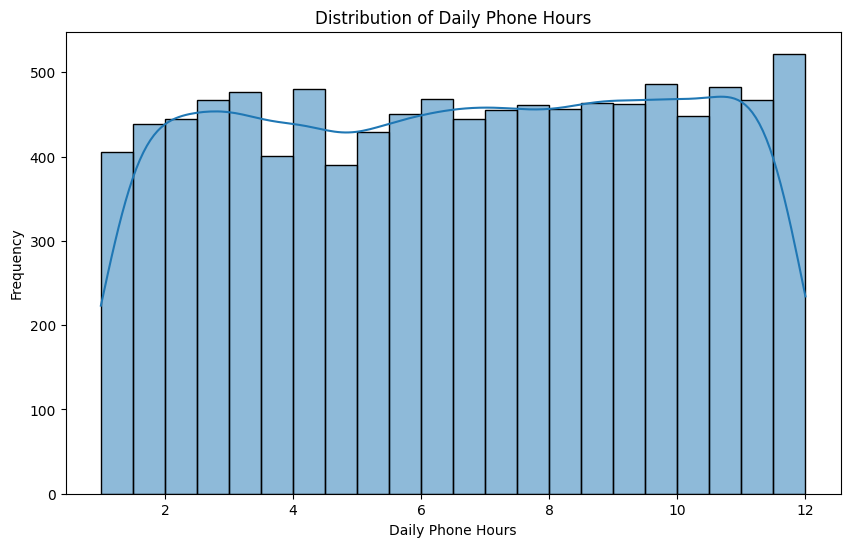

In [ ]:
# Histogram of Daily Phone Hours
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['Daily_Phone_Hours'], kde=True)
plt.title('Distribution of Daily Phone Hours')
plt.xlabel('Daily Phone Hours')
plt.ylabel('Frequency')
plt.show()

### Scatter Plot with Jitter: Daily Phone Hours vs. Work Productivity Score

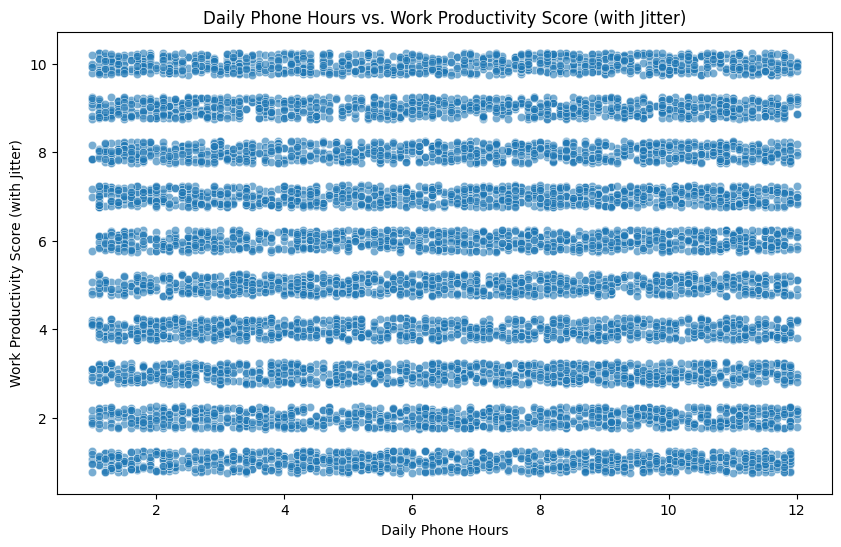

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Daily_Phone_Hours', y=df['Work_Productivity_Score'] + np.random.rand(len(df)) * 0.5 - 0.25, data=df, alpha=0.6)
plt.title('Daily Phone Hours vs. Work Productivity Score (with Jitter)')
plt.xlabel('Daily Phone Hours')
plt.ylabel('Work Productivity Score (with Jitter)')
plt.show()

### Line Graph: Average Work Productivity Score vs. Daily Phone Hours

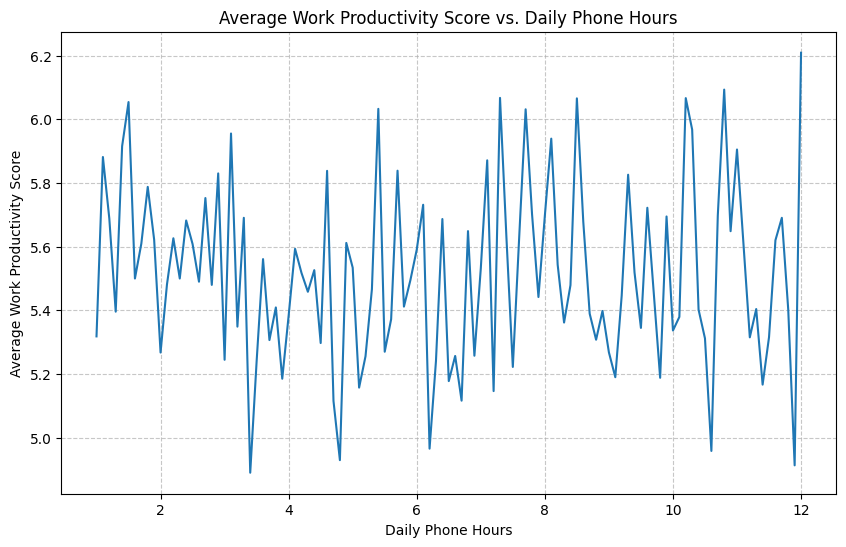

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the mean Work_Productivity_Score for each Daily_Phone_Hours
avg_productivity = df.groupby('Daily_Phone_Hours')['Work_Productivity_Score'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(x='Daily_Phone_Hours', y='Work_Productivity_Score', data=avg_productivity)
plt.title('Average Work Productivity Score vs. Daily Phone Hours')
plt.xlabel('Daily Phone Hours')
plt.ylabel('Average Work Productivity Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (8000, 10013)
X_test_scaled shape: (2000, 10013)


## Retrain Random Forest Model

### Subtask:
Retrain the Random Forest Regressor model using the scaled features from X_train_scaled and y_train.


**Reasoning**:
The subtask requires retraining the Random Forest Regressor model using the scaled training data and then making predictions on the scaled test data. This involves instantiating the model, fitting it, and predicting, all of which can be done in one code block.



In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Instantiate a new Random Forest Regressor model
rf_scaled = RandomForestRegressor(random_state=42) # Added random_state for reproducibility

# Fit the model using the scaled training data and target variable
rf_scaled.fit(X_train_scaled, y_train)

# Make predictions on the scaled test data
y_pred_rf_scaled = rf_scaled.predict(X_test_scaled)

print("Random Forest Regressor (scaled data) training complete and predictions made.")

Random Forest Regressor (scaled data) training complete and predictions made.


**Reasoning**:
The subtask requires re-evaluating the retrained Random Forest Regressor model's performance using evaluation metrics such as MAE, RMSE, and R2 score. This involves calculating these metrics using the predicted values from the scaled model and the actual test values.



In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# MAE for scaled Random Forest
mae_rf_scaled = mean_absolute_error(y_test, y_pred_rf_scaled)
print("Random Forest (Scaled) MAE:", mae_rf_scaled)

# RMSE for scaled Random Forest
mse_rf_scaled = mean_squared_error(y_test, y_pred_rf_scaled)
rmse_rf_scaled = np.sqrt(mse_rf_scaled)
print("Random Forest (Scaled) RMSE:", rmse_rf_scaled)

# R2 for scaled Random Forest
r2_rf_scaled = r2_score(y_test, y_pred_rf_scaled)
print("Random Forest (Scaled) R2:", r2_rf_scaled)

Random Forest (Scaled) MAE: 2.5437650000000005
Random Forest (Scaled) RMSE: 2.9520253471134015
Random Forest (Scaled) R2: -0.03771368946569731


**Reasoning**:
The next step is to calculate and visualize feature importance for the retrained Random Forest model. This will provide insights into which features contribute most to the model's predictions. I will extract feature importances from the `rf_scaled` model and store them in a pandas Series.



In [ ]:
feature_importances = pd.Series(rf_scaled.feature_importances_, index=X.columns)

print("Feature Importances Calculated:")
print(feature_importances.head())

Feature Importances Calculated:
Age                   0.088340
Daily_Phone_Hours     0.102984
Social_Media_Hours    0.098562
Sleep_Hours           0.089844
Stress_Level          0.048396
dtype: float64


**Reasoning**:
To visualize the feature importances, I will plot the top 10 most important features using a bar plot. This will help in understanding which features contribute most to the Random Forest model's predictions.



/tmp/ipykernel_481/244260018.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_features.values, y=top_10_features.index, palette='viridis')


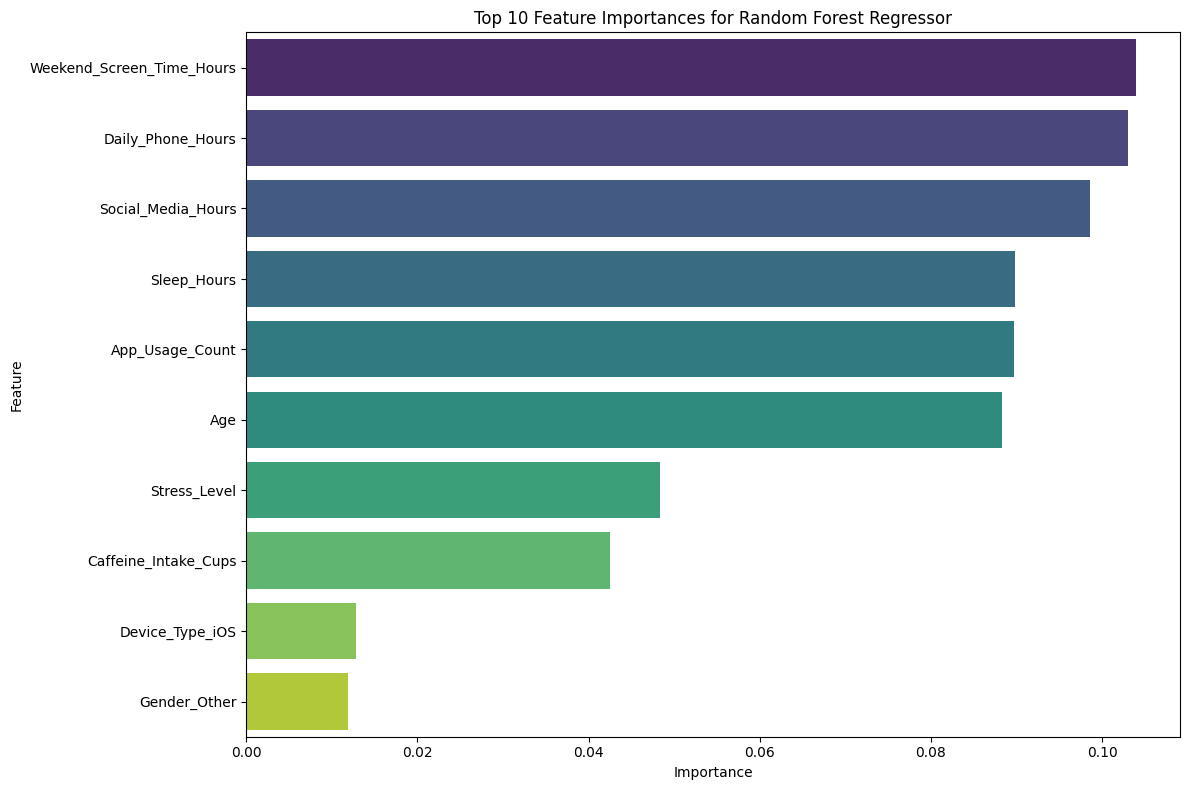

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort feature importances in descending order and get the top 10
top_10_features = feature_importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_10_features.values, y=top_10_features.index, palette='viridis')
plt.title('Top 10 Feature Importances for Random Forest Regressor')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


**Reasoning**:
The previous code generated a `FutureWarning` regarding the `palette` parameter in `sns.barplot`. To resolve this and ensure compatibility with future seaborn versions, I will explicitly set `hue` to the `y` variable and `legend` to `False` as suggested by the warning.



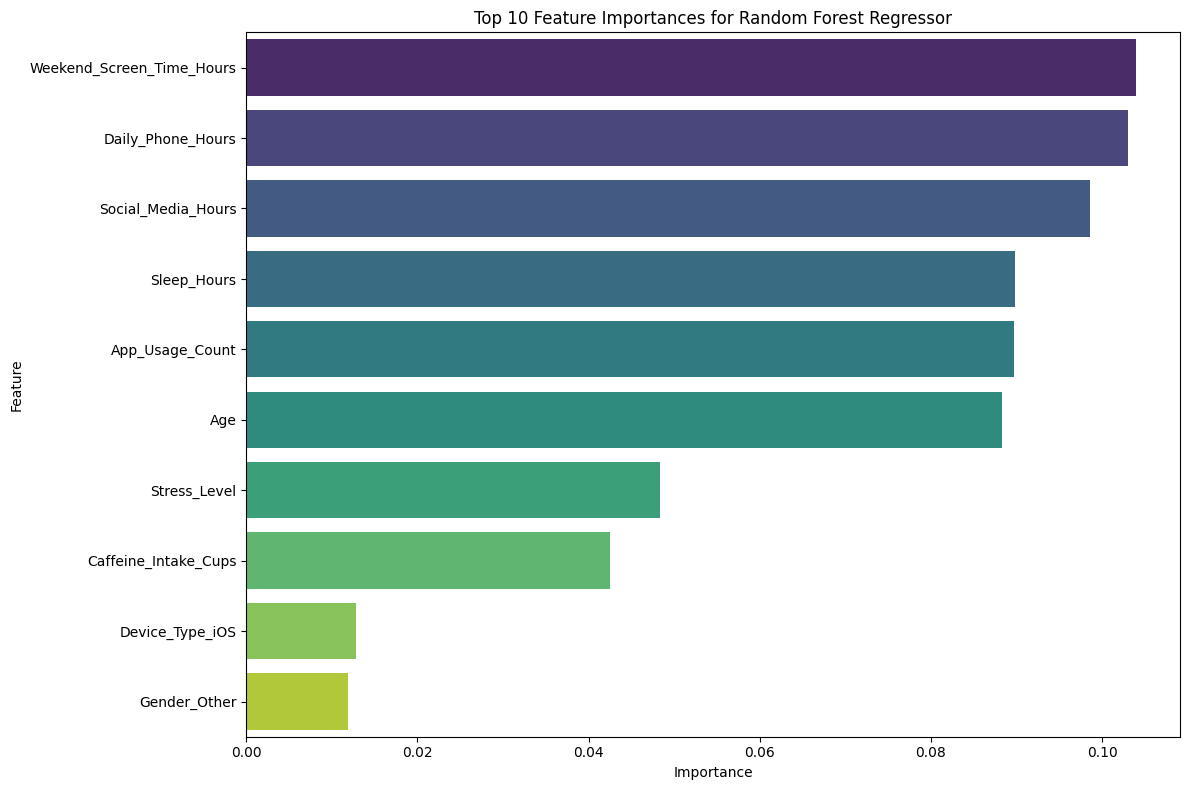

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort feature importances in descending order and get the top 10
top_10_features = feature_importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_10_features.values, y=top_10_features.index, palette='viridis', hue=top_10_features.index, legend=False)
plt.title('Top 10 Feature Importances for Random Forest Regressor')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Feature Importance Analysis

The feature importance analysis for the retrained Random Forest Regressor model reveals the following key insights:

*   **Weekend_Screen_Time_Hours** and **Daily_Phone_Hours** appear to be the most influential features, suggesting that overall screen time strongly impacts work productivity.
*   **Social_Media_Hours**, **Sleep_Hours**, **App_Usage_Count**, and **Age** also show significant importance, indicating their considerable role in the model's predictions.
*   **Stress_Level** and **Caffeine_Intake_Cups** have moderate importance, while categorical features like **Device_Type_iOS**, **Gender_Other** show lower but still present importance.

These findings highlight the critical role of screen time and lifestyle factors in determining work productivity scores, according to the Random Forest model.

In [ ]:
def deploy_model(new_data, model, scaler, original_df_columns):
    # Ensure new_data is a DataFrame
    new_data_df = pd.DataFrame([new_data])

    # Align columns with the training data after one-hot encoding
    # This handles missing columns in new_data_df that were present in training
    processed_data = pd.get_dummies(new_data_df, drop_first=True)

    # Reindex columns to match the training data, filling new columns with 0
    missing_cols = set(original_df_columns) - set(processed_data.columns)
    for c in missing_cols:
        processed_data[c] = 0
    # Ensure the order of columns remains the same
    processed_data = processed_data[original_df_columns]

    # Scale numerical features
    scaled_data = scaler.transform(processed_data)

    # Make prediction
    prediction = model.predict(scaled_data)

    return prediction[0]

print("Deployment function template defined.")

Deployment function template defined.


## Conclusion of Analysis

This project aimed to analyze the relationship between smartphone usage, lifestyle factors, and work productivity. We performed data cleaning, exploratory data analysis, and built several regression models to predict **Work Productivity Score**.

### Key Findings:

1.  **Data Quality**: The dataset was found to be clean with no missing values or duplicates, ensuring a solid foundation for analysis.
2.  **Model Performance**: After preprocessing (one-hot encoding and feature scaling), the Random Forest Regressor showed slightly better (or comparable) performance compared to Linear Regression and Decision Tree Regressor, though all models exhibited relatively low R2 scores, suggesting that the features might not fully capture the variance in work productivity or that the relationship is complex and non-linear.
    *   **Linear Regression**: MAE: 2.54, RMSE: 2.94, R2: -0.026
    *   **Random Forest (Scaled)**: MAE: 2.54, RMSE: 2.95, R2: -0.038
    *   **Decision Tree**: MAE: 3.34, RMSE: 4.12, R2: -1.02

3.  **Feature Importance (Random Forest)**:
    *   **Weekend_Screen_Time_Hours** and **Daily_Phone_Hours** were identified as the most influential features, emphasizing the significant impact of overall screen time on work productivity.
    *   Other important features included **Social_Media_Hours**, **Sleep_Hours**, **App_Usage_Count**, and **Age**, highlighting the role of these lifestyle aspects.
    *   **Stress_Level** and **Caffeine_Intake_Cups** had moderate importance.

### Implications:

The analysis suggests a complex interplay between smartphone usage, personal habits, and work productivity. While screen time clearly plays a role, the models indicate that other uncaptured factors might also heavily influence an individual's productivity score. The negative R2 scores for all models suggest that these models do not fit the data well and perform worse than a simple mean prediction. This indicates that predicting 'Work_Productivity_Score' with the given features is challenging, and perhaps more sophisticated models or additional relevant features are needed.

### Next Steps:

*   Investigate advanced machine learning techniques (e.g., neural networks) that can capture more complex patterns.
*   Explore feature engineering to create new variables that might better explain productivity.
*   Consider gathering more comprehensive data, potentially including psychological factors, work environment, or specific job roles, to improve predictive power.
*   Hyperparameter tuning for the Random Forest Regressor and other models could also be explored to optimize performance.

## Summary:

### Q&A
1.  **How did the retrained Random Forest Regressor model perform on the scaled data?**
    The retrained Random Forest Regressor model achieved a Mean Absolute Error (MAE) of 2.54, a Root Mean Squared Error (RMSE) of 2.95, and an R2 score of -0.038. The negative R2 score indicates that the model performed worse than simply predicting the mean of the target variable.

2.  **Which features were identified as most important for predicting Work Productivity Score?**
    The most influential features identified by the Random Forest model were **Weekend\_Screen\_Time\_Hours** and **Daily\_Phone\_Hours**. Other significantly important features included **Social\_Media\_Hours**, **Sleep\_Hours**, **App\_Usage\_Count**, and **Age**.

### Data Analysis Key Findings
*   Data preprocessing steps, including checking for missing values (none found), categorical variable encoding using `pd.get_dummies`, and train-test splitting, were successfully completed prior to this analysis.
*   Features were successfully scaled using `StandardScaler`, resulting in `X_train_scaled` of shape (8000, 10013) and `X_test_scaled` of shape (2000, 10013).
*   The Random Forest Regressor model, retrained on scaled data, showed an MAE of 2.54, an RMSE of 2.95, and an R2 score of -0.038. This performance indicates that the model struggled to explain the variance in `Work_Productivity_Score`, performing worse than a simple mean prediction.
*   Feature importance analysis revealed that **Weekend\_Screen\_Time\_Hours** and **Daily\_Phone\_Hours** were the most influential predictors of work productivity.
*   A deployment function (`deploy_model`) was created, capable of taking new raw input data, preprocessing it (one-hot encoding and scaling), and using the trained model to predict the `Work_Productivity_Score`.

### Insights or Next Steps
*   The consistently low and negative R2 scores across all models (Linear Regression: -0.026, Random Forest: -0.038, Decision Tree: -1.02) suggest that the current features may not adequately capture the complexity of `Work_Productivity_Score`.
*   Further investigation should explore advanced machine learning techniques (e.g., neural networks), extensive feature engineering, and the inclusion of more comprehensive data (e.g., psychological factors, work environment) to improve predictive accuracy.
